<h2>Notebook : coder un algorithme génératif DSM-Ornstein sur MNIST de manière naïve</h2>

<h3>1- Imports, chargement de mnist, préparation du dataset</h3>

In [27]:
import pandas as pd
import numpy as np
from numpy import random
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torch import nn
from torch.optim import Adam

from math import exp, sqrt
from tqdm import tqdm

In [36]:
mnist_df = pd.read_csv("mnist_test.csv", index_col=None, header=None)
mnist_df.drop(columns=[0], inplace=True) # on n'a pas besoin des labels pour notre travail !
mnist_df.shape

(10000, 784)

### 2 - Paramétrisation du processus Ornstein-Uhlenbeck.
Processus de la forme : 

$dX_t =-  \beta X_t dt + \sigma dW_t$ 

Connaissant les processus de O.U., on sait que 

$X_t | X_0 \sim \mathcal{N}(\gamma_t X_0, \sigma_t^2 I)$

avec $\gamma_t = e^{-\beta t}$, et $\sigma_t^2 = \frac{\sigma^2}{2 \beta}(1 - e^{-2\beta t})$

On pourra alors écrire :

$X_t = \gamma_t X_0 + \sigma_t \varepsilon$,

$\varepsilon \sim \mathcal{N}(0, I)$


In [29]:
T = 20 # temps d'arrivée du processus forward

n_pas = T*2 # nombre de pas dans le schéma discrétisé
t_linspace, dt = np.linspace(0, T, n_pas, retstep=True)

sigma = 0.01
beta = 1 - sigma  # paramètres du processus, choisis au hasard. Comment les optimiser, comment les choisir ?

gamma_t = np.array([exp(-(beta*t)) for t in t_linspace])
sigma_t_squared = np.array([(sigma**2 / 2*beta) * (1 - exp(-(2*beta*t))) for t in t_linspace])
sigma_t = np.array([sqrt(s) for s in sigma_t_squared])
lambda_t = np.array([1-i/n_pas for i in range(n_pas)])

On affiche dans un premier temps $X_0$ et un $X_t$ correspondant avec $t$ tiré aléatoirement dans l'espace de temps.

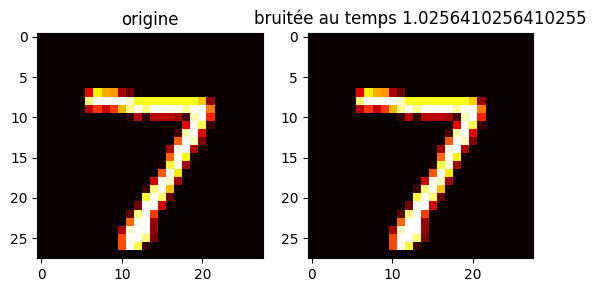

In [37]:
X_0 = np.array(mnist_df.iloc[0])
i = random.randint(n_pas)

eps = np.random.normal(0,1, 784)
t = t_linspace[i]
X_t = gamma_t[i]*X_0 + sigma_t[i]*eps

# affichage
fig, axs = plt.subplots(1, 2)
axs[0].set(title="origine")
axs[0].imshow(X_0.reshape((28,28)), cmap="hot")
axs[1].set(title=f"bruitée au temps {t:}")
axs[1].imshow(X_t.reshape((28,28)), cmap="hot")

<h3>3 - Construction du réseau de neurones et du dataloader</h3>

In [89]:
# On convertit nos données pour utilisations avec pytorch
BATCH_SIZE = 16 # pair
data_tensor = torch.tensor(mnist_df.values, dtype=torch.float32) # convertir le df en tenseur
train_dataloader = DataLoader(data_tensor, batch_size=BATCH_SIZE)

"""
# Affichage du batch
train_features = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")

fig, axes = plt.subplots(int(BATCH_SIZE/2), int(BATCH_SIZE/2))
for i in range(int(BATCH_SIZE/2)):
    for j in range(int(BATCH_SIZE/2)):
        img = train_features[i+j].squeeze()
        axes[i][j].imshow(img.reshape((28,28)), cmap="gray")
fig.show()
"""

scorer = nn.Sequential(
    nn.Linear(785, 784), # 784 pour l'image, +1 pour la coordonnées de temps t
    nn.ReLU(),
    nn.Linear(784, 784),
)

optimizer = Adam(scorer.parameters(), lr=0.1)

def predict_noise(inputs, t_vec):

    size = len(inputs)
    #
    # inputs : batch de taille BATCH_SIZE, t_vec : vecteur torch des temps observés
    # -------
    # wrapper pour scorer, qui transforme le score en estimation du bruit à partir de (X_t, t).
    # empiriquement plus efficace, et utilisé dans la réécriture de la loss, donc nécessaire dans
    # cette implémentation. Noter que ça revient à une normalisation du score.

    inputs_ = torch.cat([inputs, t_vec.reshape(-1,1)],
                        axis=1)
    inputs_ = inputs_.float()
    output_ = scorer(inputs_)

    predict = torch.empty(16,784)
    
    for k in range(size):
        predict[k] = sigma_t[k]*output_[k]*(-1)

    return predict
    

On va construire la fonction de reverse.<br>

En théorie, on applique l'algorithme suivant :<br>
$X_T \sim \mathcal{N}(0, \sigma_T ^2 I)$<br>
<i>pour $k$ allant de $T$ à $1$ faire : </i><br>
$Z \sim \mathcal{N}(0, I)$<br>
$ X_{k-1} = X_k - \Delta_t \big[ -\sigma ^2 \varepsilon_\theta(X_k,k\Delta_t) - \beta X_k \big] + \sigma\sqrt{\Delta_t}Z_k $<br>
où $\varepsilon_\theta$ est le bruit prédit par le nn entraîné.

C:\Users\mmnb6\AppData\Local\Temp\ipykernel_27960\2737581802.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b_X = torch.tensor(beta*X)
C:\Users\mmnb6\AppData\Local\Temp\ipykernel_27960\2737581802.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X)


tensor([ 8.8533e+04,  3.3154e+04, -9.1597e+04, -9.1715e+04, -5.1711e+04,
         1.2097e+05, -1.6705e+05, -1.0658e+05,  1.0008e+05,  4.3820e+04,
        -1.6091e+05,  1.3958e+05, -8.5401e+04, -3.6835e+03, -1.0022e+05,
         1.5149e+05,  1.7681e+03, -1.2888e+05, -9.5666e+04, -1.1646e+05,
         4.7235e+04, -2.1151e+04, -7.9239e+04,  3.7806e+04,  5.3823e+04,
         5.8347e+04, -8.5681e+04,  2.6107e+04, -1.1297e+04,  5.5033e+04,
         5.0612e+04,  2.8031e+04, -1.1065e+05, -5.1196e+04, -5.9416e+03,
         5.7622e+04,  2.3374e+04, -5.4773e+04, -1.4881e+05,  1.3621e+05,
        -2.1683e+05,  8.2601e+04,  3.1497e+04,  1.3928e+04,  3.5975e+04,
        -5.9206e+04, -2.4244e+04,  2.1430e+04, -2.5827e+04, -5.6898e+04,
         3.7231e+03,  6.2643e+03,  1.0535e+05,  1.9362e+04,  3.8112e+04,
        -1.1200e+05,  3.0390e+04,  1.1519e+05, -3.3846e+04, -6.1396e+04,
        -4.1798e+04,  8.5087e+04, -6.5288e+04,  3.6947e+04,  1.1316e+05,
        -2.0979e+04,  1.8476e+05, -1.0581e+05,  1.3

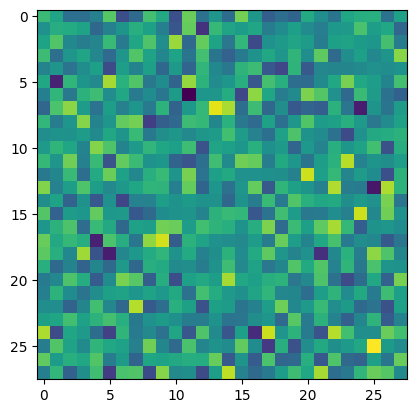

In [103]:
def generate():

    X = random.normal(0, sigma_t[T], 784)

    for k in range((n_pas-1), 0, -1):

        Z = random.normal(0, 1, 784)
        in_ = torch.tensor(np.append(X, k*dt))
        """
        print(type(in_))
        print(type(in_.float()))
        print(type(scorer(in_.float())))
        
        print(type(sigma_t[k]))
        print(type(dt))
        print(type(torch.tensor(Z)))
        
        print(type(sigma))
        print(type(sqrt(dt)))
        print(type(beta))

        print(sigma**2/sigma_t[k])
        print(dt*sigma**2/sigma_t[k]*scorer(in_.float()))
        """
        

        with torch.no_grad():        
            b_X = torch.tensor(beta*X)
            prod = dt*( (sigma**2/sigma_t[k])*scorer(in_.float()) - b_X)
            X = torch.tensor(X)
            X = X - prod + sigma*sqrt(dt)*Z
    plt.imshow(X.reshape((28,28)))
    return X

    

generate()

In [104]:
## passe d'apprentissage


for batch in tqdm(train_dataloader):
    # construction des inputs (X_t, t)
    
    idxs = [random.randint(n_pas) for i in range(BATCH_SIZE)]
    ts = torch.tensor([t_linspace[i] for i in idxs])
    gammas = torch.tensor([gamma_t[i] for i in idxs])
    sigmas = torch.tensor([sigma_t[i] for i in idxs])
    lambdas = torch.tensor([lambda_t[i] for i in idxs])
    epsilons = torch.tensor(np.array([np.random.normal(0,1, 784) for i in range(BATCH_SIZE)]))
    
    determinist_components = torch.empty(BATCH_SIZE,784)
    noise_components = torch.empty(BATCH_SIZE,784)
    for k in range(BATCH_SIZE):
        noise_components[k] = epsilons[k] * sigmas[k]
        determinist_components[k] = batch[k] * gammas[k]
    
    Xts = determinist_components + noise_components

    # entraînement à proprement parler
    
    predicted_noises = predict_noise(Xts, ts)
    losses = torch.empty(BATCH_SIZE)
    for k in range(BATCH_SIZE):
        losses[k] = torch.sum((predicted_noises[k]-epsilons[k])**2)
        losses[k] *= lambdas[k]
        losses[k] /= sigmas[k]**2
    
    loss = torch.mean(losses)
    print(loss)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


  1%|          | 6/625 [00:00<00:27, 22.43it/s]

tensor(inf, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)


  2%|▏         | 10/625 [00:00<00:21, 28.18it/s]

tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)


  4%|▍         | 26/625 [00:00<00:13, 43.33it/s]

...

tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)


 99%|█████████▊| 616/625 [00:17<00:00, 45.86it/s]

tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)


100%|██████████| 625/625 [00:17<00:00, 35.54it/s]

tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)
tensor(nan, grad_fn=<MeanBackward0>)


Génération